In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Problem #2: Reference Core

In [2]:
from astrotools.cloud import collapse as collapse
from astrotools import constants as c

In [3]:
# example core constants
T = c.T_CORE # Kelvin
n_H2 = c.N_H2_CORE # m^-3
M = c.M_CORE # kg
R_0 = c.R_CORE / 3.1e16 # 3.1e16 meters in 1 parsec

In [4]:
# Calculating Jeans mass
mass_density_H2 = collapse.number_density_to_mass_density(n_H2)
M_J = collapse.jeans_mass(T, mass_density_H2)

print("The Jeans mass for the example core is: %.4g kg" %M_J)
print("The mass of the example core is : %.4g kg" %M)
print("M_J/M_CORE = %.4g" %(M_J / M))
print("Since M_CORE > M_J, the molecular cloud is unstable, and the ratio implies it will form multiple stars")

The Jeans mass for the example core is: 3.084e+30 kg
The mass of the example core is : 5.965e+30 kg
M_J/M_CORE = 0.5169
Since M_CORE > M_J, the molecular cloud is unstable, and the ratio implies it will form multiple stars


In [5]:
# Calculating Jeans Length
# There's not a function for it in collapse.py, so I'll write one here and then incorporate it into my local collapse.py
def jeans_length(T, mass_density, mu = c.MU_CLOUD):
    c_s = np.sqrt(c.K_B * T / (mu * c.M_H))
    lambda_J = c_s * np.sqrt(np.pi / (c.G * mass_density))
    jeans_length_pc = lambda_J / 3.1e16 # 3.1e16 meters in 1 parsec
    return jeans_length_pc


jeans_length = jeans_length(T, mass_density_H2)
print("The Jeans length for the molecular cloud is: %.2g pc" %jeans_length)
print("The radius of the molecular cloud is: %.2g pc" %R_0)
print("The diameter of the cloud is: %.2g pc = %.2g Jeans lengths. This also implies that the core is unstable, since 2*R_0 > jeans length" %(2*R_0, (2*R_0/jeans_length)))

The Jeans length for the molecular cloud is: 0.061 pc
The radius of the molecular cloud is: 0.047 pc
The diameter of the cloud is: 0.093 pc = 1.5 Jeans lengths. This also implies that the core is unstable, since 2*R_0 > jeans length


In [6]:
# Calculating free-fall time
t_ff = collapse.free_fall_time(mass_density_H2)
print("The free-fall time of the molecular cloud is %.3g s" %t_ff)

The free-fall time of the molecular cloud is 3.07e+12 s


## Problem #3: Characteristic Mass

In [7]:
herschel_cores = pd.read_csv("data/herschel_core_catalog.csv")
herschel_cores

,seq,name,R_deconv_pc,R_obs_pc,M_core_msun,M_core_err_msun,T_dust_K,T_dust_err_K,N_H2_peak_cm2,N_H2_av_cm2,N_H2_avd_cm2,n_H2_peak_cm3,n_H2_av_cm3,n_H2_avd_cm3,alpha_BE,core_type,no_sed_fit,tentative_bound,co_high_vlsr
0,1,182154.6-025557,0.026,0.037,0.09,0.05,11.5,4.5,1.000000e+21,8.000000e+20,1.600000e+21,5000.0,5000.0,14000.0,5.6,starless,1,0,0
1,2,182215.5-030107,0.023,0.033,0.09,0.05,11.5,4.5,1.100000e+21,1.000000e+21,2.200000e+21,6000.0,7000.0,21000.0,4.7,starless,1,0,0
2,3,182246.4-032847,0.029,0.038,0.09,0.05,11.5,4.5,1.000000e+21,8.000000e+20,1.400000e+21,6000.0,4000.0,11000.0,6.0,starless,1,0,0
3,4,182254.4-033415,0.025,0.034,0.11,0.05,11.5,4.5,1.200000e+21,1.100000e+21,2.000000e+21,7000.0,7000.0,18000.0,4.6,starless,1,0,0
4,5,182303.8-032358,0.020,0.032,0.11,0.05,11.5,4.5,1.300000e+21,1.300000e+21,3.300000e+21,7000.0,9000.0,36000.0,3.6,prestellar,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,745,183652.5-021914,0.034,0.042,0.17,0.04,13.5,0.7,2.900000e+21,1.200000e+21,1.800000e+21,15000.0,6000.0,11000.0,3.9,prestellar,0,1,1
745,746,183652.7-021215,0.046,0.052,0.20,0.05,14.2,0.9,2.700000e+21,9.000000e+20,1.100000e+21,13000.0,4000.0,5000.0,4.5,starless,0,0,1
746,747,183652.9-021440,0.021,0.031,0.20,0.11,10.6,1.4,6.400000e+21,2.500000e+21,5.600000e+21,39000.0,17000.0,60000.0,2.0,prestellar,0,1,1
747,748,183654.2-021242,0.020,0.031,0.22,0.11,11.1,1.4,4.100000e+21,2.800000e+21,6.600000e+21,25000.0,20000.0,72000.0,1.8,prestellar,0,0,1


### Part 1

In [8]:
# I used Claude to create the two boolean masks below to pick out only the prestellar cores from the dataframe
T_cores_herschel = herschel_cores.loc[herschel_cores['core_type'] == 'prestellar', 'T_dust_K'].to_numpy()
M_cores_herschel = herschel_cores.loc[herschel_cores['core_type'] == 'prestellar', "M_core_msun"].to_numpy()
n_H2_herschel = herschel_cores.loc[herschel_cores['core_type'] == 'prestellar', 'n_H2_avd_cm3'].to_numpy() * 1e6 #cm^-3 to m^-3

# calculating the mass density and the jeans mass
mass_density_H2_herschel = collapse.number_density_to_mass_density(n_H2_herschel)
M_J_herschel = collapse.jeans_mass(T_cores_herschel, mass_density_H2_herschel)

### Part 2

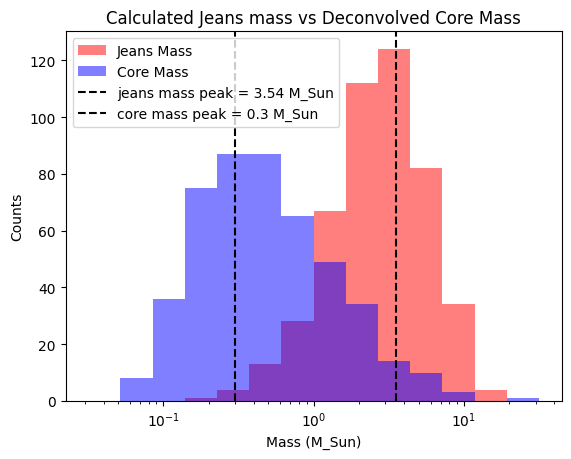

In [20]:
b = np.logspace(-1.5, 1.5, 15)
plt.xscale("log")
plt.hist(M_J_herschel/c.M_SUN, bins = b, color = 'red', alpha = 0.5, label = 'Jeans Mass')
plt.hist(M_cores_herschel, bins = b, color = 'blue', alpha = 0.5, label = 'Core Mass')
plt.title("Calculated Jeans mass vs Deconvolved Core Mass")
plt.xlabel("Mass (M_Sun)")
plt.ylabel("Counts")

#calculating the peaks from the bin counts and edges
peak_M_J = 2.6826958 + (4.39397056 - 2.6826958)/2
peak_M_cores = 0.22758459 + (0.37275937 - 0.22758459)/2

plt.axvline(x = peak_M_J, color = 'black', linestyle = '--', label = 'jeans mass peak = %.3g M_Sun' %peak_M_J)
plt.axvline(x = peak_M_cores, color = 'black', linestyle = '--', label = 'core mass peak = %.3g M_Sun' %peak_M_cores)
plt.legend()

### Part 3

In [10]:
print("The peak Jeans mass is: %.4g M_Sun" %peak_M_J)
print("The peak core mass is: %.4g M_Sun" %peak_M_cores)
print("The ratio M_J/M_core is: %.4g" %(peak_M_J/peak_M_cores))
print("The median core mass is: %.4g M_Sun" %np.median(M_cores_herschel))
print("The median Jeans mass is: %.4g M_Sun" %np.median(M_J_herschel/c.M_SUN))
print("The median ratio M_J/M_core is: %.4g" %(np.median(M_J_herschel/c.M_SUN)/np.median(M_cores_herschel)))

The peak Jeans mass is: 3.538 M_Sun
The peak core mass is: 0.3002 M_Sun
The ratio M_J/M_core is: 11.79
The median core mass is: 0.42 M_Sun
The median Jeans mass is: 2.75 M_Sun
The median ratio M_J/M_core is: 6.548


The prediction is larger by a factor of 11.79. The median ratio of 6.55 agrees with the previous ratio, in that the prediction is significantly larger than the core mass. The ratio implies a count of ~11, so one Jeans mass produces ~11 fragments. This implies that the collapse is not monolithic.

$IMF$ = $CMF$ - $e * CMF$ 

$IMF=CMF(1 - e)$ $=>$ $\frac{IMF}{CMF} = (1 - e)$ $=>$ $e = 1-\frac{IMF}{CMF}$

CMF = 0.3 M_Sun, IMF = 0.2-0.3M_sun

In [37]:
eff_factor = 1 - 0.2/0.3
print("The efficiency factor for IMF=0.2 is: %.3g = %.3g%%" %(eff_factor, (eff_factor*100)))
print("This agrees with the quoted efficiency factor")

The efficiency factor for IMF=0.2 is: 0.333 = 33.3%
This agrees with the quoted efficiency factor


## Problem #4: Collapse Timescale

#### Part 1

In [11]:
def t_life(N):
    t_II = 2 #Myrs
    N_II = 622 #num of Class II stellar objects

    return (N * t_II/N_II)

In [12]:
# picking density thresholds
N_thresholds = np.linspace(1e10, 1e12, 100) #picking 100 threshold densities

# counting the number of cores that are above a threshold density for all 100 thresholds
t_lifetime_arr = []
for N in N_thresholds:
    N_greater_n_count = (n_H2_herschel > N).sum()
    t_lifetime = t_life(N_greater_n_count)
    t_lifetime_arr = np.append(t_lifetime_arr, t_lifetime)

Text(0.5, 1.0, 'Time spent above density, n, for a range of threshold densities')

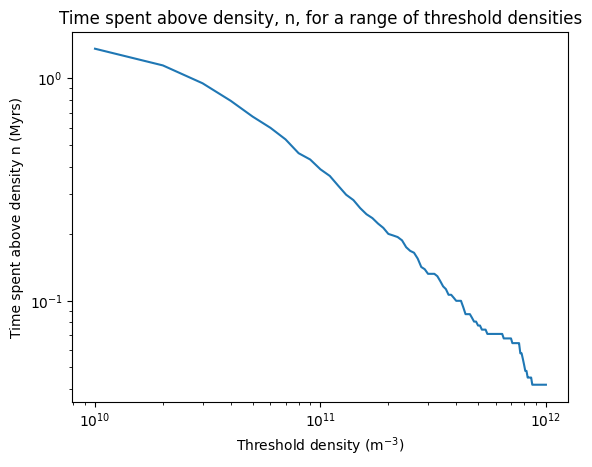

In [13]:
plt.plot(N_thresholds, t_lifetime_arr)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Threshold density (m$^{-3}$)")
plt.ylabel("Time spent above density n (Myrs)")
plt.title("Time spent above density, n, for a range of threshold densities")

#### Part 2

In [14]:
# converting number density to mass density
mass_density_thresholds = collapse.number_density_to_mass_density(N_thresholds)

# calculating t_ff
t_ff_thresholds = collapse.free_fall_time(mass_density_thresholds)

#converting seconds to Myrs in t_ff
t_ff_thresholds_Myr = t_ff_thresholds / (60 * 60 * 24 * 365 * 1e6)

Text(0.5, 1.0, 'Free-fall time for a range of threshold densities')

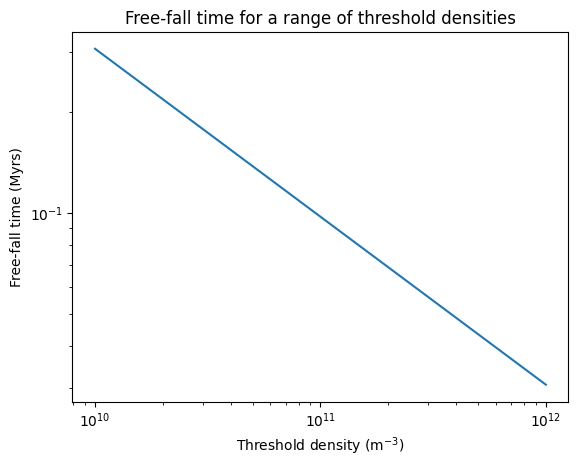

In [15]:
plt.plot(N_thresholds, t_ff_thresholds_Myr)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Threshold density (m$^{-3}$)")
plt.ylabel("Free-fall time (Myrs)")
plt.title("Free-fall time for a range of threshold densities")

### Part 3 & 4

In [16]:
# fitting a straight line
def f(x, m, b):
    y = m*x + b
    return y

In [17]:
# using curve_fit to fit a straight line to the data
popt, pcov = curve_fit(f, t_lifetime_arr, t_ff_thresholds_Myr)

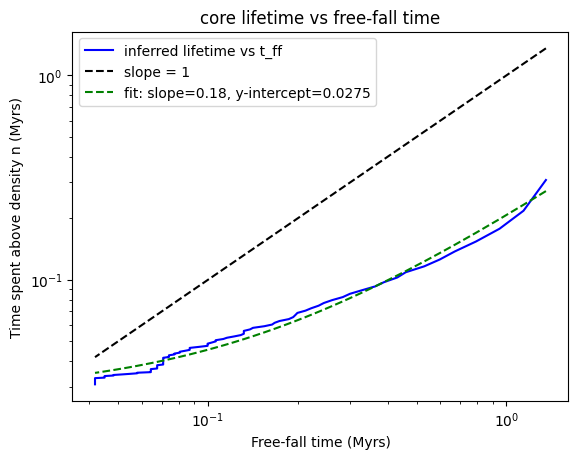

In [18]:
plt.plot(t_lifetime_arr, t_ff_thresholds_Myr, color = 'blue', label = 'inferred lifetime vs t_ff')
plt.plot(t_lifetime_arr, t_lifetime_arr, color = 'black', linestyle = '--', label = 'slope = 1')
plt.plot(t_lifetime_arr, f(t_lifetime_arr, *popt), color = 'green', linestyle = '--', label='fit: slope=%.3g, y-intercept=%.3g' % tuple(popt))
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Free-fall time (Myrs)")
plt.ylabel("Time spent above density n (Myrs)")
plt.title("core lifetime vs free-fall time")
plt.legend()

In [19]:
print("The slope of the fit is: %.3g" %popt[0])
print("The mean ratio, t_life / t_ff is: %.4g" %np.mean(t_lifetime_arr/t_ff_thresholds_Myr))

The slope of the fit is: 0.18
The mean ratio, t_life / t_ff is: 2.274


1. The measured lifetime does not scale with density the way free-fall does; both are inversely proportional to the density, however, the slope of the fit is a 0.18, while if they scales the same way, we would expect a slope closer to 1. Slope is a better test over the mean ratio because it more precisely describes how the two scale compared to eachother.

2. The mean ratio is 2.274, which tells us that the lifetimes are that much longer than the free-fall times; the cores collapse slower than the free-fall time. My guess is that since the cloud is efficient at radiating heat, the radiation produces an outward radiation pressure that slows the collapse.

3. If the core were long-lived structures, the slope of the plot would eventually become much greater than 1, since the slope of the lifetime-to-number-density would be nearly constant in y for changing x. I would look for a slope with a magnitude much greater than 1.